In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

In [4]:
master_df = pd.read_csv("../data/processed/master_dataset_v2.csv")
df = master_df.copy()

In [5]:
df.head()

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp
0,Alabama,2008,4718206.0,1.746656e+11,37019.49,2582600.0,0.547369,33441.0,42219.0,88.901
1,Alabama,2009,4757938.0,1.708765e+11,35913.98,2479511.0,0.521131,32717.0,41966.0,87.786
2,Alabama,2010,4788095.0,1.775107e+11,37073.35,2460305.0,0.513838,33848.0,41709.0,89.783
3,Alabama,2011,4812576.0,1.828967e+11,38003.91,2497974.0,0.519051,34884.0,41819.0,90.011
4,Alabama,2012,4839947.0,1.882807e+11,38901.40,2503656.0,0.517290,35559.0,41592.0,90.559


# 1. Income vs Real Income

### Does higher income actually mean better living standards?

- We examined whether higher income leads to higher real income, which reflects the actual purchasing power per capita

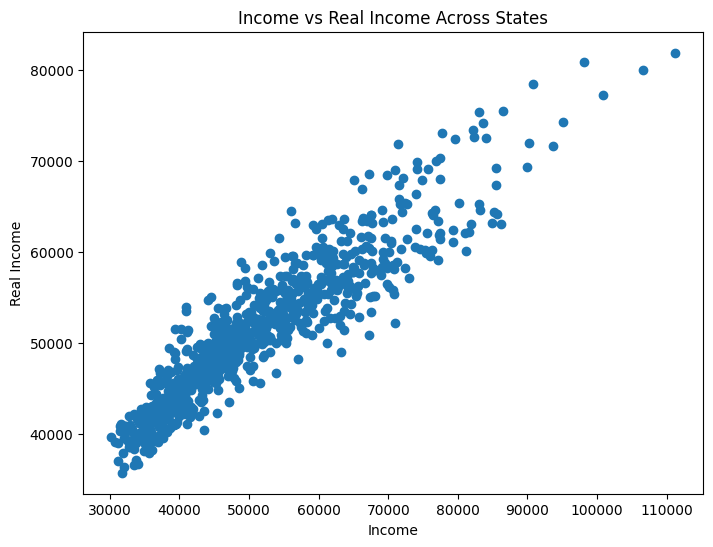

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(df["income_pc"], df["real_income_pc"])

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title("Income vs Real Income Across States")

plt.show()

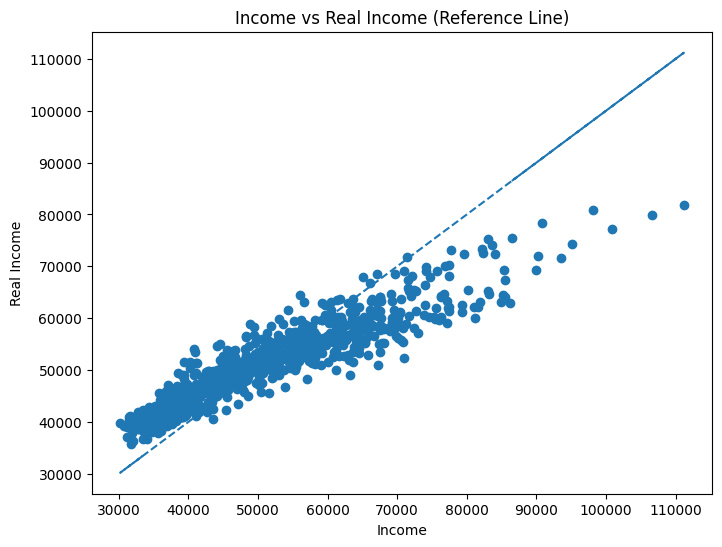

Correlation = 0.92


In [7]:
x = df["income_pc"]
y = df["real_income_pc"]

plt.figure(figsize=(8,6))
plt.scatter(x, y)

# reference line

plt.plot(x, x, linestyle='--')

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title("Income vs Real Income (Reference Line)")

plt.show()

# correlation
corr = df["income_pc"].corr(df["real_income_pc"])
print(F"Correlation = {corr:.2f}")

In [8]:
x = df["income_pc"]
y = df["real_income_pc"]

slope, intercept = np.polyfit(x, y, 1)

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.2f}")

Slope: 0.5497
Intercept: 23160.45


In [9]:
X = df["income_pc"]
y = df["real_income_pc"]

# Add constant for intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         real_income_pc   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     5118.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:05:18   Log-Likelihood:                -8158.1
No. Observations:                 867   AIC:                         1.632e+04
Df Residuals:                     865   BIC:                         1.633e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.316e+04    406.853     56.926      0.0

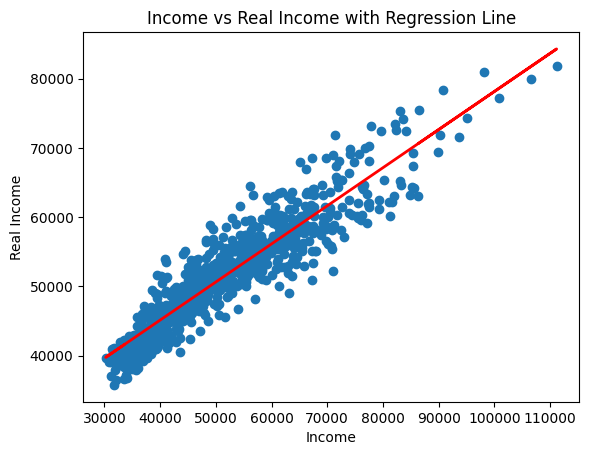

In [10]:
# add regession to graph

plt.scatter(df["income_pc"], df["real_income_pc"])
plt.plot(df["income_pc"], model.predict(X), color='red', linewidth=2)

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title("Income vs Real Income with Regression Line")

plt.show()

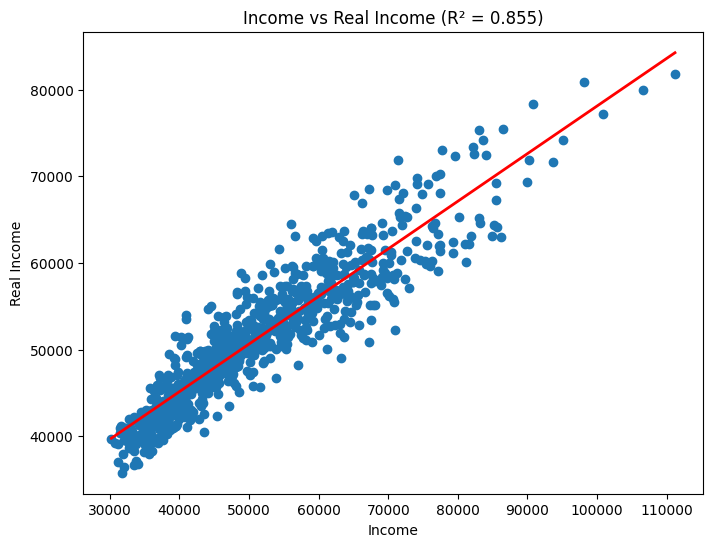

In [11]:
df_sorted = df.sort_values("income_pc")

X_sorted = sm.add_constant(df_sorted["income_pc"])
y_pred_sorted = model.predict(X_sorted)

plt.figure(figsize=(8,6))

# scatter (original data)
plt.scatter(df["income_pc"], df["real_income_pc"])

# regression line (sorted)
plt.plot(df_sorted["income_pc"], y_pred_sorted, color='red', linewidth=2)

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title(f"Income vs Real Income (R² = {model.rsquared:.3f})")

plt.show()

In [12]:
#residuals

df["predicted"] = model.predict(X)
df["residual"] = df["real_income_pc"] - df["predicted"]


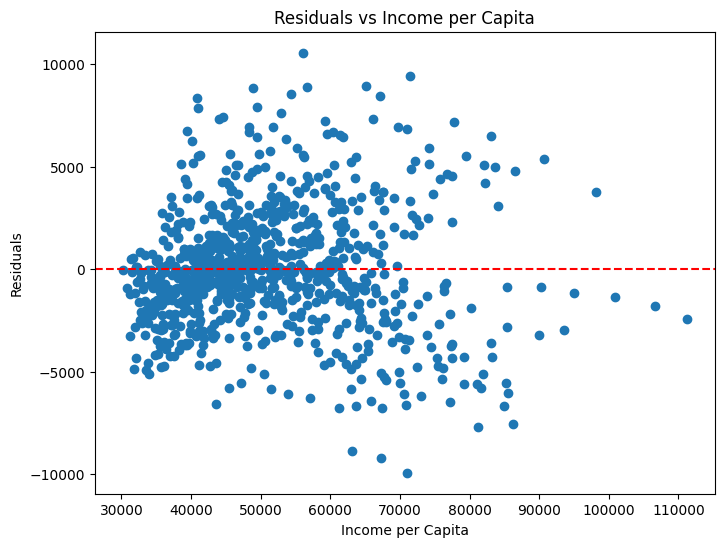

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(df["income_pc"], df["residual"])
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Income per Capita")
plt.ylabel("Residuals")
plt.title("Residuals vs Income per Capita")
plt.show()

In [13]:
# worst
df.sort_values("residual").head(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
203,Hawaii,2024,1434952.0,1.176274e+11,81973.06,928210.0,0.646858,71019.0,52272.0,109.951,62197.338934,-9925.338934
202,Hawaii,2023,1434950.0,1.117402e+11,77870.45,918356.0,0.639992,67269.0,50923.0,109.703,60136.082911,-9213.082911
201,Hawaii,2022,1437812.0,1.039545e+11,72300.48,895965.0,0.623145,63184.0,49022.0,111.148,57890.688018,-8868.688018
83,California,2023,39181667.0,3.827007e+12,97673.42,25260641.0,0.644706,81196.0,60100.0,112.195,67791.312944,-7691.312944
84,California,2024,39364774.0,4.048108e+12,102835.80,25583169.0,0.649900,86232.0,63028.0,110.720,70559.442365,-7531.442365
644,Oregon,2023,4250392.0,3.148950e+11,74086.11,2683848.0,0.631435,67467.0,53455.0,104.812,60244.917229,-6789.917229
200,Hawaii,2021,1446909.0,9.368420e+10,64747.82,860689.0,0.594847,61264.0,50046.0,112.564,56835.324934,-6789.324934
526,New Jersey,2024,9506354.0,8.460004e+11,88993.15,6069474.0,0.638465,84893.0,63142.0,108.805,69823.436548,-6681.436548
643,Oregon,2022,4245964.0,2.970843e+11,69968.63,2618298.0,0.616656,63669.0,51501.0,106.612,58157.277130,-6656.277130
645,Oregon,2024,4265324.0,3.302501e+11,77426.73,2707024.0,0.634658,70823.0,55451.0,103.361,62089.603952,-6638.603952


In [14]:
#best
df.sort_values("residual").tail(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
592,North Dakota,2022,780191.0,7.505210e+10,96197.09,581410.0,0.745215,71011.0,69036.0,88.703,62192.941587,6843.058413
704,South Dakota,2015,852029.0,4.867890e+10,57132.91,592644.0,0.695568,48308.0,56644.0,87.799,49713.822794,6930.177206
587,North Dakota,2017,766807.0,5.653020e+10,73721.55,573077.0,0.747355,51830.0,58594.0,88.664,51649.754450,6944.245550
711,South Dakota,2022,909156.0,6.942560e+10,76362.69,641124.0,0.705186,69752.0,68469.0,87.851,61500.909232,6968.090768
864,Wyoming,2022,581742.0,4.957040e+10,85210.28,430968.0,0.740823,77768.0,73081.0,91.767,65907.050105,7173.949895
860,Wyoming,2018,574783.0,3.961450e+10,68920.79,404591.0,0.703902,59197.0,62928.0,92.372,55699.160615,7228.839385
591,North Dakota,2021,777977.0,6.483000e+10,83331.51,567429.0,0.729365,66158.0,66878.0,90.962,59525.401460,7352.598540
580,North Dakota,2010,675097.0,3.565180e+10,52809.89,503803.0,0.746268,44081.0,54744.0,89.083,47390.375006,7353.624994
700,South Dakota,2011,823113.0,4.208270e+10,51126.27,566491.0,0.688230,44532.0,55061.0,87.272,47638.275397,7422.724603
585,North Dakota,2015,762814.0,5.695220e+10,74660.66,597638.0,0.783465,52972.0,59886.0,91.063,52277.475618,7608.524382


In [15]:
#state avg residual

state_avg = df.groupby("state")["residual"].mean().sort_values()

In [16]:
state_avg.head(10)   # worst states


state
Hawaii       -6009.316933
California   -3690.960814
Arizona      -3622.675614
Oregon       -3372.718587
Utah         -2912.443527
New Mexico   -2547.027089
Florida      -2405.625774
Nevada       -1972.298793
Idaho        -1819.490626
New York     -1812.031549
Name: residual, dtype: float64

In [17]:
state_avg.tail(10)   # best states

state
Massachusetts           1702.759704
Oklahoma                2091.862282
District of Columbia    2832.788836
Kansas                  2842.868514
Iowa                    3008.551949
Connecticut             3583.110446
Nebraska                4304.066310
Wyoming                 5997.098694
South Dakota            6062.249377
North Dakota            6916.492631
Name: residual, dtype: float64

In [29]:
df["income_group"] = pd.qcut(df["income_pc"], 4, labels=["Low", "Mid-Low", "Mid-High", "High"])
df.groupby("income_group")["residual"].mean()

income_group
Low        -742.770082
Mid-Low     296.109826
Mid-High    895.118355
High       -444.333130
Name: residual, dtype: float64

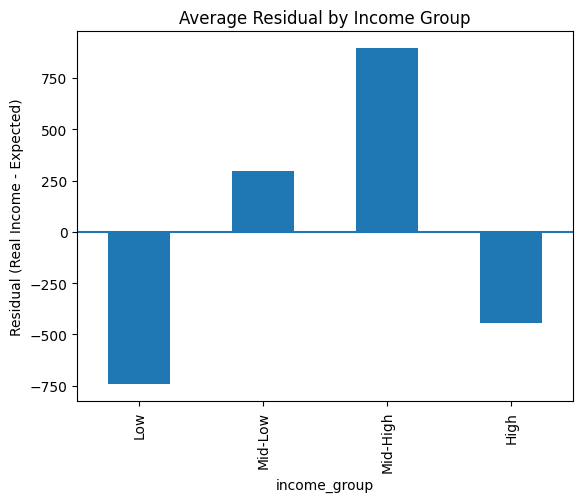

In [35]:
ax = df.groupby("income_group")["residual"].mean().plot(kind="bar")

plt.axhline(0)  # center line at zero

plt.ylabel("Residual (Real Income - Expected)")
plt.title("Average Residual by Income Group")

plt.show()

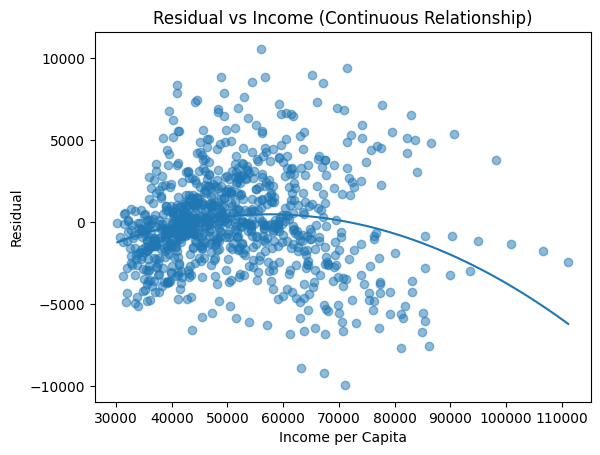

In [24]:
plt.scatter(df["income_pc"], df["residual"], alpha=0.5)

# Fit a simple curve
z = np.polyfit(df["income_pc"], df["residual"], 2)  # quadratic
p = np.poly1d(z)

x_vals = np.linspace(df["income_pc"].min(), df["income_pc"].max(), 100)
plt.plot(x_vals, p(x_vals))

plt.xlabel("Income per Capita")
plt.ylabel("Residual")
plt.title("Residual vs Income (Continuous Relationship)")
plt.show()

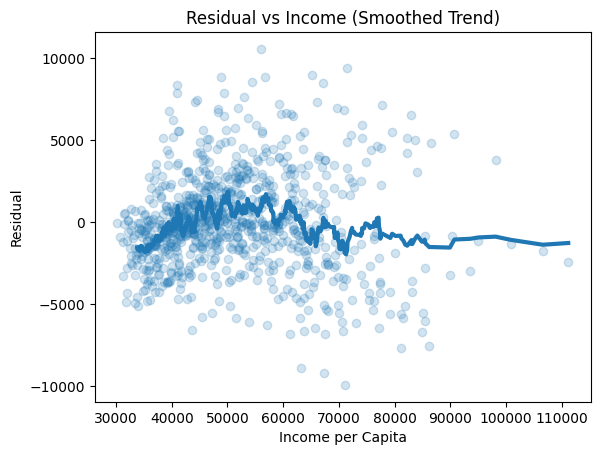

In [ ]:
df_sorted = df.sort_values("income_pc")
df_sorted["rolling_residual"] = df_sorted["residual"].rolling(window=30).mean()

plt.scatter(df["income_pc"], df["residual"], alpha=0.2)
plt.plot(df_sorted["income_pc"], df_sorted["rolling_residual"], linewidth=3)

plt.xlabel("Income per Capita")
plt.ylabel("Residual")
plt.title("Residual vs Income (Smoothed Trend)")
plt.show()

In [33]:
groups = [group["residual"].values for name, group in df.groupby("income_group")]

f_stat, p_value = stats.f_oneway(*groups)
print(p_value)

5.157852483249228e-09


In [18]:
df["gdp"].corr(df["residual"])

np.float64(-0.26940229066479787)

In [20]:
df["gdp_pc"].corr(df["residual"])

np.float64(0.09064243935153606)

As GDP increases, residuals tend to decrease (moderate corr)

- States with larger economies tend to underperform in real income relative to expectations

### Insights

- Income and real income are strongly correlated (R² = 0.855)
- The relationship is not perfect, indicating variation across states
- Some states outperform or underperform expected real income levels
- This suggests that income alone does not determine economic well-being
- Cost of living is likely a key factor influencing these differences